# Calculate dimensionality of neural activity

Notebook created: 7/1/26
Studying multiload models

Duplicated from dimensionality_v1  
This became more of a trajectory-plotting notebook of the maintenance period though, so changing name to reflect that  

UPDATED:
- adding load2 trials
- testing across models

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

from sklearn.decomposition import PCA

2026-07-02 15:22:39.467297: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 15:22:39.475361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-02 15:22:39.484377: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-02 15:22:39.487094: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-02 15:22:39.494412: I tensorflow/core/platform/cpu_feature_guar

In [2]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

condn_phrase = 'delay'
condn_num = 150

In [3]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}


## PCA on maintenance period only

### one model

In [4]:
model_name = model_names[10]

other_labels='precomputed_balanced123'
_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)

trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels,
        all_models_dir=all_models_dir
    )

# calculate rates during maintenance period for correct trials
correct_idxs = np.where(trial_perfs == 1)[0]
rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

# cut trials to maintenance period only
rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
for i in range(rates_corr.shape[0]):
    load = trial_labels_corr[i, 0]
    delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
    delay_end = int(delay_start + settings["delay"])
    rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

# get all loads
load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

# get dimensionality for each load
load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
load2_rates = rates_maint[load2_idxs, :, :] # trials x neurons x time
load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

# PCA of all loads together
n_trials_load1, n_neurons, n_time = load1_rates.shape
n_trials_load2, _, _ = load2_rates.shape
n_trials_load3, _, _ = load3_rates.shape
load1_vectors = load1_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load2_vectors = load2_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load3_vectors = load3_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons

X = np.concatenate([load1_vectors, load2_vectors,    load3_vectors], axis=0)  # trials x neurons
mu, sd = X.mean(0), X.std(0)
Xz = (X - mu) / sd

pca = PCA(n_components=300)
scores = pca.fit_transform(Xz)  # trials x components

n1 = load1_vectors.shape[0]
n2 = load2_vectors.shape[0]
n3 = load3_vectors.shape[0]
scores1, scores2, scores3 = scores[:n1], scores[n1:n1+n2], scores[n1+n2:n1+n2+n3]

load1_comps = scores1.reshape(n_trials_load1, n_time, -1) # trials x time x components
load2_comps = scores2.reshape(n_trials_load2, n_time, -1) # trials x time x components
load3_comps = scores3.reshape(n_trials_load3, n_time, -1) # trials x time x components

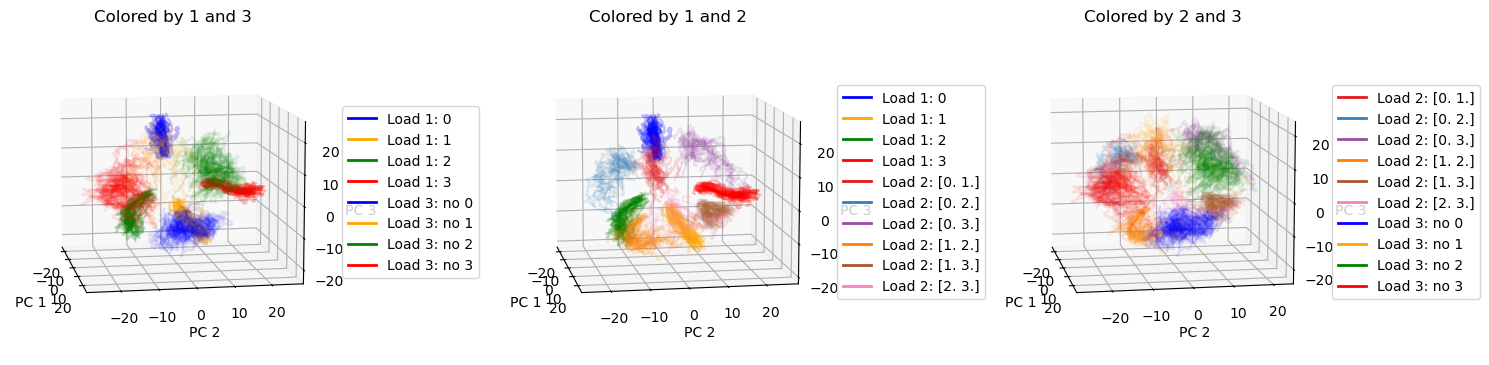

In [11]:
# plot PCs 1, 2, 3
plot_PCs = [0, 1, 2]  # zero-indexed

fig = plt.figure(figsize=(15,6))

colors = ['blue','orange','green','red']

# color by load1 stim1
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1
colors1 = [colors[load1_stims[j]] for j in range(n_trials_load1)]
handles1 = [
    plt.Line2D([], [], color=colors[i], lw=2, label=f"Load 1: {combo}")
    for i, combo in enumerate(range(4))]

load2_labels_noorder = np.sort(trial_labels_corr[load2_idxs, 2:4], axis=1)  # sort stim1 and stim2 for each trial
trial_combos, combo_labels = np.unique(load2_labels_noorder, axis=0, return_inverse=True)  # unique stim1/2 combinations for load 2
n_combos = len(trial_combos)
colors2 = plt.cm.Set1(np.linspace(0, 1, n_combos+1))[combo_labels]
handles2 = [
    plt.Line2D([], [], color=plt.cm.Set1(i / n_combos), lw=2, label=f"Load 2: {combo}")
    for i, combo in enumerate(trial_combos)]

label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
colors3 = [colors[label_leftout[j]] for j in range(n_trials_load3)]
handles3 = [
    plt.Line2D([], [], color=colors[i], lw=2, label=f"Load 3: no {combo}")
    for i, combo in enumerate(range(4))]

ax = fig.add_subplot(1,3,1, projection='3d')
for j in range(n_trials_load1):
    ax.plot(load1_comps[j, :, plot_PCs[0]], load1_comps[j, :, plot_PCs[1]], load1_comps[j, :, plot_PCs[2]], color=colors1[j], alpha=0.25)
for j in range(n_trials_load3):
    ax.plot(load3_comps[j, :, plot_PCs[0]], load3_comps[j, :, plot_PCs[1]], load3_comps[j, :, plot_PCs[2]], color=colors3[j], alpha=0.10)
ax.set_xlabel(f'PC {plot_PCs[0] + 1}')
ax.set_ylabel(f'PC {plot_PCs[1] + 1}')
ax.set_zlabel(f'PC {plot_PCs[2] + 1}')
ax.legend(handles=handles1 + handles3, loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_title('Colored by 1 and 3')
ax.view_init(elev=10, azim=-10)


ax = fig.add_subplot(1,3,2, projection='3d')
for j in range(n_trials_load1):
    ax.plot(load1_comps[j, :, plot_PCs[0]], load1_comps[j, :, plot_PCs[1]], load1_comps[j, :, plot_PCs[2]], color=colors1[j], alpha=0.25)
for j in range(n_trials_load2):
    ax.plot(load2_comps[j, :, plot_PCs[0]], load2_comps[j, :, plot_PCs[1]], load2_comps[j, :, plot_PCs[2]], color=colors2[j], alpha=0.15)
ax.set_xlabel(f'PC {plot_PCs[0] + 1}')
ax.set_ylabel(f'PC {plot_PCs[1] + 1}')
ax.set_zlabel(f'PC {plot_PCs[2] + 1}')
ax.legend(handles=handles1 + handles2, loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_title('Colored by 1 and 2')
ax.view_init(elev=10, azim=-10)


ax = fig.add_subplot(1,3,3, projection='3d')
for j in range(n_trials_load2):
    ax.plot(load2_comps[j, :, plot_PCs[0]], load2_comps[j, :, plot_PCs[1]], load2_comps[j, :, plot_PCs[2]], color=colors2[j], alpha=0.15)
for j in range(n_trials_load3):
    ax.plot(load3_comps[j, :, plot_PCs[0]], load3_comps[j, :, plot_PCs[1]], load3_comps[j, :, plot_PCs[2]], color=colors3[j], alpha=0.10)
ax.set_xlabel(f'PC {plot_PCs[0] + 1}')
ax.set_ylabel(f'PC {plot_PCs[1] + 1}')
ax.set_zlabel(f'PC {plot_PCs[2] + 1}')
ax.legend(handles=handles2 + handles3, loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_title('Colored by 2 and 3')
ax.view_init(elev=10, azim=-10)

plt.tight_layout()
plt.show()

Nice set of observations — these map onto a few standard quantitative tools from the population-geometry literature (Bernardi et al. 2020, Panichello & Buschman, dPCA-style analyses). Here's how I'd break it down into concrete stats, and I'd do all of this in the full-dimensional neural space (or a cross-validated subspace), not just the 3 PCs you're plotting — the PCA plot is great for showing the reader, but stats computed on a display axis chosen post-hoc are somewhat circular.
1. Quantify the clustering itself: decoding, not distance-by-eye
For each load, train a cross-validated linear classifier (linear SVM, logistic regression, or LDA — LDA is nice here because it directly targets separability) to decode the condition label from population activity during the maintenance period:

- Load-1: decode which of the 4 stimuli was shown (4-way classification)
- Load-2: decode which of the 6 unordered pairs was shown
- Load-3: decode which of the 4 unordered triples was shown (equivalently, which item was left out — 4-way)

Use k-fold or leave-one-trial-out cross-validation, report accuracy against chance, and build a null distribution by shuffling labels within load and repeating (permutation test, ~1000 shuffles) to get a p-value rather than just eyeballing "above chance." This turns "keeps them in a cluster" into a number with a confidence interval.  
You can supplement this with unsupervised cluster-quality metrics computed on the same full-dimensional data — silhouette score or a simple within-cluster/between-cluster distance ratio — again compared to a shuffled-label null.

2. Quantify the "opposite direction" relationship
This is the more interesting claim and there are a couple of complementary ways to nail it down:
Centroid-vector cosine similarity. For each stimulus X, compute the load-1 centroid for "X shown" (μ1_X) and the load-3 centroid for "X excluded" (μ3_¬X), both relative to a common reference point (grand mean across all trials is a reasonable choice). Compute the cosine similarity between (μ1_X − reference) and (μ3_¬X − reference). If your visual impression is right, this should cluster near −1 across the 4 stimuli, well below what you'd get from randomly paired conditions. Build a null by computing cosine similarities between mismatched pairs (e.g., μ1_X vs μ3_¬Y for X≠Y) or by shuffling condition labels, and test whether the true matched-pair cosine similarities are significantly more negative.
Cross-condition decoder generalization (this one is the most rigorous single test). Train a linear decoder on load-1 trials only, one-vs-rest, to find the axis that best separates "stimulus X present" from "stimulus X absent" within load-1. Then project the load-3 trials onto that same axis (don't retrain). If coding is genuinely antipodal, load-3 trials that include X should project to the "absent" side of that axis, and load-3 trials that exclude X should project to the "present" side — i.e., a full sign flip relative to what you'd naively expect. Quantify with a t-test or permutation test comparing projection values for load-3-includes-X vs load-3-excludes-X trials, and check the sign matches the flipped prediction. This is nice because it's a genuine out-of-condition generalization test, not just a description of the same data you clustered.

3. Representational similarity analysis (RSA), as a complementary/confirmatory approach
Build a representational dissimilarity matrix (pairwise distances or 1−correlation) across all condition centroids — load-1 identities, load-2 pairs, load-3 triples — in full neural space. Then construct a model RDM that encodes your hypothesis explicitly (e.g., predicted maximal distance between load-1-X and load-3-¬X, closer distance between load-1-X and load-3 triples that contain X), and correlate the model RDM with the neural RDM (Spearman, tested via permutation of condition labels). This is a good way to formally state "opposite direction" as a hypothesis and see how well it accounts for the whole geometry at once, not just the four X-vs-¬X pairs.

4. Optional but powerful: demixed PCA (dPCA)
Since you have identity, load, and set-membership as crossed factors, dPCA will explicitly find components that capture stimulus-identity variance while marginalizing out load — this could directly show you whether there's a shared "identity axis" that flips sign between presence (load-1) and absence (load-3), and how much variance it explains relative to load or interaction components. It's a nice complement to the decoding approach because it's about explained variance structure rather than classification accuracy.
One caveat worth flagging in your write-up: your PCA was fit on all trials pooled, so the low-D visualization and any stats computed directly on those 3 PCs share the same fitting data — mention this, and ideally confirm your key numbers (decoding accuracy, cosine similarities) hold up when computed in full neural dimensionality or with cross-validated PCA (fit PCA on a train split, project a held-out split) rather than only on the plotted components.
If you want, I can sketch actual code (Python/numpy + sklearn) for the decoder-generalization test and the cosine-similarity permutation test — those two together would probably make your strongest figure panels.

## load-1 vs load-3

### cosine similarity

#### one model

In [16]:
# quantify angle relationships between load1, load2, and load3 trajectories in PCA space

from itertools import combinations, permutations

def get_centroid(X, mask):
    """Mean population vector across trials satisfying mask."""
    return X[mask].mean(axis=0)

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def cosine_opposite_test(X, load1_labels, load3_labels, n_stimuli=4, n_perm=1000, seed=0):
    """
    X: (n_trials, n_neurons) population activity, maintenance-period average,
       for load-1 and load-3 trials pooled together.
    load1_labels: array, len n_trials, entries in {0,1,2,3,None/nan} -- the stimulus
                  shown on load-1 trials (nan/None for non-load-1 trials).
    load3_labels: array, len n_trials, entries are sets/tuples of 3 stimulus ids
                  for load-3 trials (None for non-load-3 trials). Use frozenset or
                  sorted tuple, e.g. (0,1,2).
    Returns dict with per-stimulus cosine sims, mean, and permutation p-value.
    """
    rng = np.random.default_rng(seed)

    # reference point: grand mean across ALL trials passed in
    ref = X.mean(axis=0)

    stimuli = list(range(n_stimuli))

    # --- centroids ---
    load1_centroids = {}
    load3_excl_centroids = {}  # keyed by excluded stimulus
    for s in stimuli:
        mask1 = np.array([lbl == s for lbl in load1_labels])
        load1_centroids[s] = get_centroid(X, mask1) - ref

        # load-3 trials that EXCLUDE stimulus s (i.e. s is the left-out one)
        mask3 = np.array([
            (trip is not None) and (s not in trip) for trip in load3_labels
        ])
        load3_excl_centroids[s] = get_centroid(X, mask3) - ref

    # --- true matched-pair cosine similarities ---
    true_sims = {
        s: cosine_sim(load1_centroids[s], load3_excl_centroids[s])
        for s in stimuli
    }
    true_mean = np.mean(list(true_sims.values()))

    # --- null distribution: mismatched pairs (load1_X vs load3_excl_Y, X != Y) ---
    mismatched_sims = [
        cosine_sim(load1_centroids[x], load3_excl_centroids[y])
        for x, y in combinations(stimuli, 2)
    ] + [
        cosine_sim(load1_centroids[y], load3_excl_centroids[x])
        for x, y in combinations(stimuli, 2)
    ]
    mismatched_mean = np.mean(mismatched_sims)

    # --- permutation test: shuffle which load-3 "excluded stimulus" label
    #     goes with which centroid, recompute mean matched-pair cosine sim ---
    # perm_means = np.zeros(n_perm)
    # load3_excl_list = [load3_excl_centroids[s] for s in stimuli]
    # for i in range(n_perm):
    #     perm = rng.permutation(stimuli)
    #     perm_sims = [
    #         cosine_sim(load1_centroids[s], load3_excl_centroids[perm_s])
    #         for s, perm_s in zip(stimuli, perm)
    #     ]
    #     perm_means[i] = np.mean(perm_sims)
    
    # return {
    #     "per_stimulus_cosine_sim": true_sims,
    #     "true_mean_cosine_sim": true_mean,
    #     "mismatched_mean_cosine_sim": mismatched_mean,
    #     "perm_null_mean": perm_means.mean(),
    #     "perm_null_std": perm_means.std(),
    #     "p_value": p_val,
    # }

    exact_perm_means = []
    for perm in permutations(stimuli):
        sims = [cosine_sim(load1_centroids[s], load3_excl_centroids[p]) 
                for s, p in zip(stimuli, perm)]
        exact_perm_means.append(np.mean(sims))
    exact_perm_means = np.array(exact_perm_means)
    exact_p = np.mean(exact_perm_means <= true_mean)

    return {
        "per_stimulus_cosine_sim": true_sims,
        "true_mean_cosine_sim": true_mean,
        "mismatched_mean_cosine_sim": mismatched_mean,
        "perm_null_mean": exact_perm_means.mean(),
        "perm_null_std": exact_perm_means.std(),
        "p_value": exact_p,
    }
    

In [ ]:
'''
X: (n_trials, n_neurons) population activity, maintenance-period average,
    for load-1 and load-3 trials pooled together.
load1_labels: array, len n_trials, entries in {0,1,2,3,None/nan} -- the stimulus
                shown on load-1 trials (nan/None for non-load-1 trials).
load3_labels: array, len n_trials, entries are sets/tuples of 3 stimulus ids
                for load-3 trials (None for non-load-3 trials). Use frozenset or
                sorted tuple, e.g. (0,1,2).
'''


# pass in X (trials x neurons, avg over maintenance period)
load1_mean = np.mean(load1_rates, axis=2)  # trials x neurons
load3_mean = np.mean(load3_rates, axis=2)  # trials x neurons
X = np.concatenate([load1_mean, load3_mean], axis=0)  # trials x neurons

# create load1_labels and load3_labels arrays
load_1or3_idxs = np.concatenate([load1_idxs, load3_idxs], axis=0)
load1_labels = np.array([label[2] if label[0] == 1 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-1 stim labels, None for non-load-1 trials
load3_labels = np.array([frozenset(label[2:5]) if label[0] == 3 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-3 stim labels, None for non-load-3 trials

In [ ]:
results = cosine_opposite_test(X, load1_labels, load3_labels, n_stimuli=4, n_perm=1000, seed=0)
results

_Per-stimulus cosine similarities_  
All four stimuli show cosine similarities between the load-1 "X present" direction and the load-3 "X excluded" direction in the range -0.72 to -0.87.   
That's consistent across stimuli, and close to -1 (perfect antipodal alignment). This is your quantitative confirmation of the visual impression: the population vector coding "stimulus X is in working memory" during load-1 points in almost exactly the opposite direction from the population vector coding "stimulus X is the one not in working memory" during load-3.  

*True mean vs. mismatched mean*  
Matched pairs (X present vs. X excluded): mean cosine sim = -0.81  
Mismatched pairs (X present vs. Y excluded, X≠Y): mean cosine sim = +0.20  
It's not just that load-1 and load-3 centroids happen to live in "opposite-ish" parts of state space in some generic sense — the mismatched pairs are actually mildly positively aligned. So the near-perfect anti-alignment is specific to the correct identity correspondence (X vs. not-X), not a generic property of load-1-vs-load-3 geometry. That's a much stronger and more specific claim than "load-1 and load-3 point in different directions" — it's "the code for presence of X is quantitatively the negation of the code for absence of X."  

*The permutation test*  
The null distribution (shuffling which load-3 excluded-stimulus centroid gets paired with which load-1 stimulus centroid) has mean ≈ -0.04 and SD ≈ 0.27. Your true mean of -0.81 is about 2.9 SDs below that null mean, giving p = 0.035. So the true identity-matched pairing is significantly more anti-aligned than you'd expect from a random pairing of the same four load-1 and four load-3 vectors.

In [ ]:
# bootstrap the cosine similarities for good measure

def cosine_bootstrap_ci(X, load1_labels, load3_labels, n_stimuli=4,
                         n_boot=1000, ci=95, seed=0):
    """
    Trial-level bootstrap CI for the load1-vs-load3 cosine similarity test.

    Resamples trials WITH REPLACEMENT within each condition (each load-1
    stimulus group, each load-3 excluded-stimulus group, and the reference
    pool), recomputes centroids, and recomputes cosine similarities.
    Repeats n_boot times to build a distribution.

    Returns per-stimulus and overall-mean bootstrap distributions + CIs.
    """
    rng = np.random.default_rng(seed)
    stimuli = list(range(n_stimuli))

    # precompute trial indices for each condition once
    load1_idx = {
        s: np.where(np.array([lbl == s for lbl in load1_labels]))[0]
        for s in stimuli
    }
    load3_excl_idx = {
        s: np.where(np.array([
            (trip is not None) and (s not in trip) for trip in load3_labels
        ]))[0]
        for s in stimuli
    }
    all_idx = np.arange(X.shape[0])  # reference pool = all trials passed in

    boot_per_stim = {s: np.zeros(n_boot) for s in stimuli}
    boot_mean = np.zeros(n_boot)

    for b in range(n_boot):
        # resample reference (grand mean) from all trials
        ref_sample = rng.choice(all_idx, size=len(all_idx), replace=True)
        ref = X[ref_sample].mean(axis=0)

        boot_sims = []
        for s in stimuli:
            # resample load-1 trials for stimulus s
            i1 = rng.choice(load1_idx[s], size=len(load1_idx[s]), replace=True)
            c1 = X[i1].mean(axis=0) - ref

            # resample load-3 trials excluding stimulus s
            i3 = rng.choice(load3_excl_idx[s], size=len(load3_excl_idx[s]), replace=True)
            c3 = X[i3].mean(axis=0) - ref

            sim = cosine_sim(c1, c3)
            boot_per_stim[s][b] = sim
            boot_sims.append(sim)

        boot_mean[b] = np.mean(boot_sims)

    alpha = (100 - ci) / 2
    results = {}
    for s in stimuli:
        lo, hi = np.percentile(boot_per_stim[s], [alpha, 100 - alpha])
        results[s] = {
            "boot_mean": boot_per_stim[s].mean(),
            "boot_std": boot_per_stim[s].std(),
            "ci_low": lo,
            "ci_high": hi,
        }

    lo, hi = np.percentile(boot_mean, [alpha, 100 - alpha])
    results["overall"] = {
        "boot_mean": boot_mean.mean(),
        "boot_std": boot_mean.std(),
        "ci_low": lo,
        "ci_high": hi,
    }

    results["_raw"] = {"per_stimulus": boot_per_stim, "mean": boot_mean}

    return results

In [19]:
boot_results = cosine_bootstrap_ci(X, load1_labels, load3_labels,
                                     n_stimuli=4, n_boot=1000, ci=95, seed=0)

for s in range(4):
    r = boot_results[s]
    print(f"Stim {s}: mean={r['boot_mean']:.3f}, "
          f"95% CI=[{r['ci_low']:.3f}, {r['ci_high']:.3f}]")

r = boot_results["overall"]
print(f"Overall mean: {r['boot_mean']:.3f}, "
      f"95% CI=[{r['ci_low']:.3f}, {r['ci_high']:.3f}]")

Stim 0: mean=-0.852, 95% CI=[-0.873, -0.829]
Stim 1: mean=-0.717, 95% CI=[-0.756, -0.679]
Stim 2: mean=-0.781, 95% CI=[-0.823, -0.736]
Stim 3: mean=-0.862, 95% CI=[-0.881, -0.837]
Overall mean: -0.803, 95% CI=[-0.815, -0.787]


#### across models

In [20]:
results_dicts = []

for model_name in model_names:

    other_labels='precomputed_balanced123'
    _, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                                all_models_dir = all_models_dir, load_LFP=False)

    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )

    # calculate rates during maintenance period for correct trials
    correct_idxs = np.where(trial_perfs == 1)[0]
    rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
    trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

    # cut trials to maintenance period only
    rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
    for i in range(rates_corr.shape[0]):
        load = trial_labels_corr[i, 0]
        delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
        delay_end = int(delay_start + settings["delay"])
        rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

    # get all loads
    load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
    load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
    load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

    # get dimensionality for each load
    load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
    load2_rates = rates_maint[load2_idxs, :, :] # trials x neurons x time
    load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

    '''
    X: (n_trials, n_neurons) population activity, maintenance-period average,
        for load-1 and load-3 trials pooled together.
    load1_labels: array, len n_trials, entries in {0,1,2,3,None/nan} -- the stimulus
                    shown on load-1 trials (nan/None for non-load-1 trials).
    load3_labels: array, len n_trials, entries are sets/tuples of 3 stimulus ids
                    for load-3 trials (None for non-load-3 trials). Use frozenset or
                    sorted tuple, e.g. (0,1,2).
    '''


    # pass in X (trials x neurons, avg over maintenance period)
    load1_mean = np.mean(load1_rates, axis=2)  # trials x neurons
    load3_mean = np.mean(load3_rates, axis=2)  # trials x neurons
    X = np.concatenate([load1_mean, load3_mean], axis=0)  # trials x neurons

    # create load1_labels and load3_labels arrays
    load_1or3_idxs = np.concatenate([load1_idxs, load3_idxs], axis=0)
    load1_labels = np.array([label[2] if label[0] == 1 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-1 stim labels, None for non-load-1 trials
    load3_labels = np.array([frozenset(label[2:5]) if label[0] == 3 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-3 stim labels, None for non-load-3 trials

    results = cosine_opposite_test(X, load1_labels, load3_labels, n_stimuli=4, n_perm=1000, seed=0)
    results_dicts.append(results)
    

In [21]:
results_dicts

[{'per_stimulus_cosine_sim': {0: -0.8932501034974099,
   1: -0.8377846947743064,
   2: -0.8118915012418967,
   3: -0.8676124177859067},
  'true_mean_cosine_sim': -0.8526346793248799,
  'mismatched_mean_cosine_sim': 0.20214380778892974,
  'perm_null_mean': -0.06155081398952264,
  'perm_null_std': 0.2679765624139511,
  'p_value': 0.041666666666666664},
 {'per_stimulus_cosine_sim': {0: -0.916636175590083,
   1: -0.9011395565988443,
   2: -0.9239123679048681,
   3: -0.8423465098374591},
  'true_mean_cosine_sim': -0.8960086524828136,
  'mismatched_mean_cosine_sim': 0.25206757599773255,
  'perm_null_mean': -0.03495148112240399,
  'perm_null_std': 0.3745053298104498,
  'p_value': 0.041666666666666664},
 {'per_stimulus_cosine_sim': {0: -0.8938025291765843,
   1: -0.7715188675443608,
   2: -0.840363213974328,
   3: -0.7337823710035075},
  'true_mean_cosine_sim': -0.8098667454246952,
  'mismatched_mean_cosine_sim': 0.20499003954237013,
  'perm_null_mean': -0.048724156699396205,
  'perm_null_std'

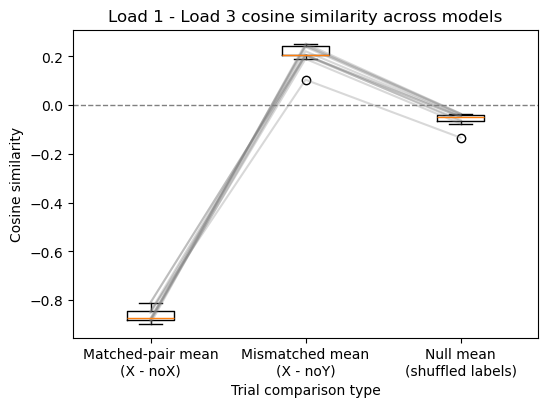

In [28]:
# plot as boxplots

mean_stimulus_cosine_sims = [results["true_mean_cosine_sim"] for results in results_dicts]
mismatched_mean_cosine_sims = [results["mismatched_mean_cosine_sim"] for results in results_dicts]
null_mean_cosine_sims = [results["perm_null_mean"] for results in results_dicts]

plt.figure(figsize=(6,4))
plt.boxplot([mean_stimulus_cosine_sims, mismatched_mean_cosine_sims, null_mean_cosine_sims])
# thin gray connecting lines for each model
for i in range(len(mean_stimulus_cosine_sims)):
    plt.plot([1, 2, 3], [mean_stimulus_cosine_sims[i], mismatched_mean_cosine_sims[i], null_mean_cosine_sims[i]], color='gray', alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.xticks([1,2,3], ['Matched-pair mean\n(X - noX)', 'Mismatched mean\n(X - noY)', 'Null mean\n(shuffled labels)'])
plt.xlabel('Trial comparison type')
plt.ylabel('Cosine similarity')
plt.title('Load 1 - Load 3 cosine similarity across models')
plt.show()

### decoding

#### one model

In [32]:
model_name = model_names[10]

other_labels='precomputed_balanced123'
_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)

trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels,
        all_models_dir=all_models_dir
    )

# calculate rates during maintenance period for correct trials
correct_idxs = np.where(trial_perfs == 1)[0]
rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

# cut trials to maintenance period only
rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
for i in range(rates_corr.shape[0]):
    load = trial_labels_corr[i, 0]
    delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
    delay_end = int(delay_start + settings["delay"])
    rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

# get all loads
load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

# get dimensionality for each load
load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
load2_rates = rates_maint[load2_idxs, :, :] # trials x neurons x time
load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

# PCA of all loads together
n_trials_load1, n_neurons, n_time = load1_rates.shape
n_trials_load2, _, _ = load2_rates.shape
n_trials_load3, _, _ = load3_rates.shape
load1_vectors = load1_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load2_vectors = load2_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load3_vectors = load3_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons

X = np.concatenate([load1_vectors, load2_vectors,    load3_vectors], axis=0)  # trials x neurons
mu, sd = X.mean(0), X.std(0)
Xz = (X - mu) / sd

pca = PCA(n_components=300)
scores = pca.fit_transform(Xz)  # trials x components

n1 = load1_vectors.shape[0]
n2 = load2_vectors.shape[0]
n3 = load3_vectors.shape[0]
scores1, scores2, scores3 = scores[:n1], scores[n1:n1+n2], scores[n1+n2:n1+n2+n3]

load1_comps = scores1.reshape(n_trials_load1, n_time, -1) # trials x time x components
load2_comps = scores2.reshape(n_trials_load2, n_time, -1) # trials x time x components
load3_comps = scores3.reshape(n_trials_load3, n_time, -1) # trials x time x components

In [36]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from scipy import stats

def cross_condition_generalization(X, load1_labels, load3_labels, n_stimuli=4,
                                     n_folds=5, seed=0, C=1.0):
    """
    Train a linear decoder on load-1 trials (stim-X present vs. not-X)
    and test generalization to load-3 trials, asking whether the decoder's
    projection flips sign appropriately for load-3-includes-X vs.
    load-3-excludes-X trials.

    X: (n_trials, n_neurons) population activity, maintenance-period average
    load1_labels: len n_trials, entries in {0,1,2,3,None} for load-1 trials
    load3_labels: len n_trials, entries are frozenset/tuple of 3 stim ids
                  for load-3 trials, None otherwise

    Returns per-stimulus and pooled results.
    """
    rng = np.random.default_rng(seed)
    stimuli = list(range(n_stimuli))

    load1_mask = np.array([lbl is not None for lbl in load1_labels])
    load3_mask = np.array([trip is not None for trip in load3_labels])

    results = {}
    all_proj_includes, all_proj_excludes = [], []

    for s in stimuli:
        # --- load-1 trials: label = 1 if stim s shown, else 0 ---
        idx1 = np.where(load1_mask)[0]
        y1 = np.array([1 if load1_labels[i] == s else 0 for i in idx1])
        X1 = X[idx1]

        # cross-validate the decoder axis on load-1 data itself (sanity check
        # that load-1 decoding works), then refit on ALL load-1 trials to get
        # the final axis used for the load-3 projection
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        cv_acc = []
        for train_idx, test_idx in cv.split(X1, y1):
            clf = LinearSVC(C=C, max_iter=10000)
            clf.fit(X1[train_idx], y1[train_idx])
            cv_acc.append(clf.score(X1[test_idx], y1[test_idx]))

        # final decoder trained on all load-1 trials for stim s
        clf_final = LinearSVC(C=C, max_iter=10000)
        clf_final.fit(X1, y1)
        w = clf_final.coef_.flatten()
        w = w / np.linalg.norm(w)  # unit vector, direction only

        # --- project load-3 trials onto this axis ---
        idx3 = np.where(load3_mask)[0]
        includes_s = np.array([s in load3_labels[i] for i in idx3])
        excludes_s = ~includes_s

        proj = X[idx3] @ w  # signed projection onto decoder axis
        proj_includes = proj[includes_s]
        proj_excludes = proj[excludes_s]

        # t-test: do includes-X and excludes-X trials differ in projection?
        t_stat, p_val = stats.ttest_ind(proj_includes, proj_excludes)

        # sign check: decoder's "positive" direction = "stim X present" in load-1.
        # antipodal hypothesis predicts load-3-excludes-X projects to POSITIVE side
        # (mimicking "present"-like coding) and load-3-includes-X to NEGATIVE side.
        predicted_flip = proj_excludes.mean() < proj_includes.mean()

        results[s] = {
            "load1_cv_accuracy": np.mean(cv_acc),
            "load3_includes_proj_mean": proj_includes.mean(),
            "load3_excludes_proj_mean": proj_excludes.mean(),
            "diff_excludes_minus_includes": proj_excludes.mean() - proj_includes.mean(),
            "t_stat": t_stat,
            "p_value": p_val,
            "matches_antipodal_prediction": predicted_flip,
        }

        all_proj_includes.append(proj_includes)
        all_proj_excludes.append(proj_excludes)

    # pooled test across all stimuli together
    pooled_includes = np.concatenate(all_proj_includes)
    pooled_excludes = np.concatenate(all_proj_excludes)
    t_pooled, p_pooled = stats.ttest_ind(pooled_excludes, pooled_includes)

    results["pooled"] = {
        "t_stat": t_pooled,
        "p_value": p_pooled,
        "mean_diff": pooled_excludes.mean() - pooled_includes.mean(),
        "n_flips_matching_prediction": sum(
            results[s]["matches_antipodal_prediction"] for s in stimuli
        ),
        "n_stimuli": n_stimuli,
    }

    return results

In [34]:
# pass in X (trials x neurons, avg over maintenance period)
load1_mean = np.mean(load1_rates, axis=2)  # trials x neurons
load3_mean = np.mean(load3_rates, axis=2)  # trials x neurons
X = np.concatenate([load1_mean, load3_mean], axis=0)  # trials x neurons

# create load1_labels and load3_labels arrays
load_1or3_idxs = np.concatenate([load1_idxs, load3_idxs], axis=0)
load1_labels = np.array([label[2] if label[0] == 1 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-1 stim labels, None for non-load-1 trials
load3_labels = np.array([frozenset(label[2:5]) if label[0] == 3 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-3 stim labels, None for non-load-3 trials

In [37]:
gen_results = cross_condition_generalization(X, load1_labels, load3_labels,
                                                n_stimuli=4, n_folds=5, seed=0)

for s in range(4):
    r = gen_results[s]
    print(f"Stim {s}: load1 CV acc={r['load1_cv_accuracy']:.2f}, "
          f"excludes-includes diff={r['diff_excludes_minus_includes']:.3f}, "
          f"p={r['p_value']:.4f}, matches prediction={r['matches_antipodal_prediction']}")

print(gen_results["pooled"])

Stim 0: load1 CV acc=1.00, excludes-includes diff=-0.638, p=0.0000, matches prediction=True
Stim 1: load1 CV acc=1.00, excludes-includes diff=-0.574, p=0.0000, matches prediction=True
Stim 2: load1 CV acc=1.00, excludes-includes diff=-0.549, p=0.0000, matches prediction=True
Stim 3: load1 CV acc=1.00, excludes-includes diff=-0.620, p=0.0000, matches prediction=True
{'t_stat': -53.77662149120646, 'p_value': 7.220891836303e-312, 'mean_diff': -0.5871105347453158, 'n_flips_matching_prediction': 4, 'n_stimuli': 4}


##### small visualization

In [ ]:
def plot_all_stimuli_clean(X, load1_labels, load3_labels, decoder_axes, ref=None):
    """
    decoder_axes: dict {stim: w}, unit-norm decoder axis per stimulus.
    Produces one row of subplots, one per stimulus.
    """
    n_stimuli = len(decoder_axes)
    fig, axes = plt.subplots(1, n_stimuli, figsize=(4.5 * n_stimuli, 5))
    if n_stimuli == 1:
        axes = [axes]
    if ref is None:
        ref = np.zeros(X.shape[1])

    load1_mask = np.array([lbl is not None for lbl in load1_labels])
    load3_mask = np.array([trip is not None for trip in load3_labels])
    idx1, idx3 = np.where(load1_mask)[0], np.where(load3_mask)[0]

    for ax, (stim, w) in zip(axes, decoder_axes.items()):
        y1 = np.array([load1_labels[i] == stim for i in idx1])
        proj1_present = (X[idx1][y1] - ref) @ w
        proj1_absent  = (X[idx1][~y1] - ref) @ w
        includes = np.array([stim in load3_labels[i] for i in idx3])
        proj3_includes = (X[idx3][includes] - ref) @ w
        proj3_excludes = (X[idx3][~includes] - ref) @ w

        groups = [proj1_present, proj1_absent, proj3_includes, proj3_excludes]
        labels = ["L1\npresent", "L1\nabsent", "L3\nincludes", "L3\nexcludes"]
        colors = ["#1f77b4", "#1f77b4", "#d62728", "#d62728"]
        alphas = [1.0, 0.4, 1.0, 0.4]

        positions = np.arange(1, 5)
        rng = np.random.default_rng(0)
        for pos, g, c, a in zip(positions, groups, colors, alphas):
            jitter = rng.normal(0, 0.06, size=len(g))
            ax.scatter(np.full(len(g), pos) + jitter, g, color=c,
                       alpha=a * 0.6, s=16, edgecolor="none", zorder=2)
        bp = ax.boxplot(groups, positions=positions, widths=0.35,
                         showfliers=False, patch_artist=True, zorder=3)
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.15); patch.set_edgecolor(c)

        ax.axhline(0, color="gray", linestyle="--", linewidth=1, zorder=1)
        ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(f"Stim {stim}", fontsize=11)
        if ax is axes[0]:
            ax.set_ylabel("Projection onto load-1 decoder axis")

    fig.suptitle("Load-1 vs. load-3 projections onto stimulus-specific decoder axes")
    fig.tight_layout()
    return fig

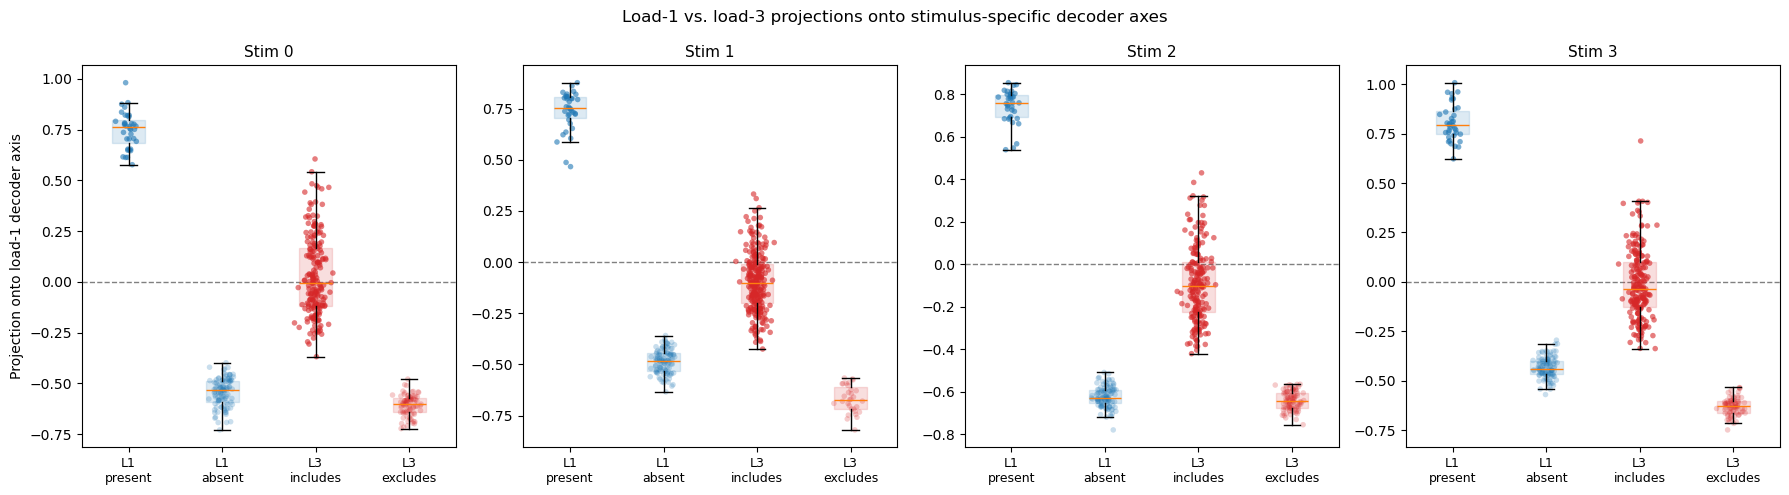

In [39]:
decoder_axes = {}
for s in range(4):
    idx1 = np.where(np.array([lbl is not None for lbl in load1_labels]))[0]
    y1 = np.array([1 if load1_labels[i] == s else 0 for i in idx1])
    clf = LinearSVC(C=1.0, max_iter=10000).fit(X[idx1], y1)
    decoder_axes[s] = clf.coef_.flatten() / np.linalg.norm(clf.coef_.flatten())

fig = plot_all_stimuli_clean(X, load1_labels, load3_labels, decoder_axes)
plt.show()

#### across models

In [40]:
def compute_normalized_projections(X, load1_labels, load3_labels, decoder_axes,
                                     ref=None):
    """
    For one model: compute mean projection per group (L1 present, L1 absent,
    L3 includes, L3 excludes), pooled across stimuli, normalized so that
    L1-absent = -1 and L1-present = +1 within this model.

    decoder_axes: dict {stim: w}, unit-norm decoder axis per stimulus.
    Returns dict with the 4 normalized group means (scalars, pooled over stimuli).
    """
    if ref is None:
        ref = np.zeros(X.shape[1])

    load1_mask = np.array([lbl is not None for lbl in load1_labels])
    load3_mask = np.array([trip is not None for trip in load3_labels])
    idx1, idx3 = np.where(load1_mask)[0], np.where(load3_mask)[0]

    present_all, absent_all, includes_all, excludes_all = [], [], [], []

    for stim, w in decoder_axes.items():
        y1 = np.array([load1_labels[i] == stim for i in idx1])
        proj1_present = (X[idx1][y1] - ref) @ w
        proj1_absent  = (X[idx1][~y1] - ref) @ w

        includes = np.array([stim in load3_labels[i] for i in idx3])
        proj3_includes = (X[idx3][includes] - ref) @ w
        proj3_excludes = (X[idx3][~includes] - ref) @ w

        # normalize THIS stimulus's axis so present mean -> +1, absent mean -> -1
        lo, hi = proj1_absent.mean(), proj1_present.mean()
        scale = (hi - lo) / 2
        mid = (hi + lo) / 2
        norm = lambda v: (v - mid) / scale

        present_all.append(norm(proj1_present).mean())
        absent_all.append(norm(proj1_absent).mean())
        includes_all.append(norm(proj3_includes).mean())
        excludes_all.append(norm(proj3_excludes).mean())

    # pool across the 4 stimuli within this model
    return {
        "L1 present": np.mean(present_all),
        "L1 absent": np.mean(absent_all),
        "L3 includes": np.mean(includes_all),
        "L3 excludes": np.mean(excludes_all),
    }


def plot_projections_across_models(all_model_results, figsize=(7, 5)):
    """
    all_model_results: list of dicts, one per model, each from
    compute_normalized_projections() -- i.e. len == n_models, each dict has
    keys "L1 present", "L1 absent", "L3 includes", "L3 excludes".
    """
    categories = ["L1 present", "L1 absent", "L3 includes", "L3 excludes"]
    n_models = len(all_model_results)

    data = np.array([[m[cat] for cat in categories] for m in all_model_results])
    # data shape: (n_models, 4)

    fig, ax = plt.subplots(figsize=figsize)
    positions = np.arange(1, 5)

    # individual model trajectories (faint gray lines + open circles)
    for row in data:
        ax.plot(positions, row, color="gray", alpha=0.35, linewidth=1, zorder=1,
                marker="o", markersize=4, markerfacecolor="none")

    # boxplot summary across models
    bp = ax.boxplot([data[:, i] for i in range(4)], positions=positions,
                     widths=0.35, showfliers=False, patch_artist=True, zorder=2)
    colors = ["#1f77b4", "#1f77b4", "#d62728", "#d62728"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.25); patch.set_edgecolor(c)
    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(0, color="gray", linestyle="--", linewidth=1, zorder=0)
    ax.axhline(1, color="gray", linestyle=":", linewidth=0.7, zorder=0)
    ax.axhline(-1, color="gray", linestyle=":", linewidth=0.7, zorder=0)
    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Normalized projection\n(L1 absent = -1, L1 present = +1)")
    ax.set_title(f"Load-1 vs. load-3 projections across {n_models} models")
    fig.tight_layout()
    return fig

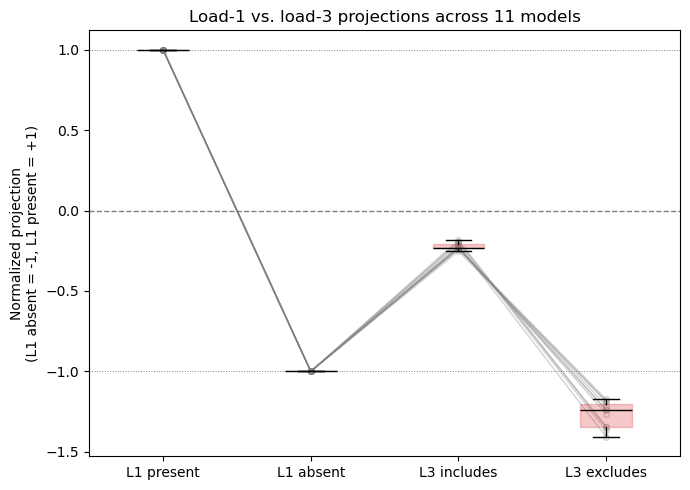

In [41]:
all_model_results = []

for model_name in model_names:

    other_labels='precomputed_balanced123'
    _, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                                all_models_dir = all_models_dir, load_LFP=False)

    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )

    # calculate rates during maintenance period for correct trials
    correct_idxs = np.where(trial_perfs == 1)[0]
    rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
    trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

    # cut trials to maintenance period only
    rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
    for i in range(rates_corr.shape[0]):
        load = trial_labels_corr[i, 0]
        delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
        delay_end = int(delay_start + settings["delay"])
        rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

    # get all loads
    load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
    load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
    load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

    # get dimensionality for each load
    load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
    load2_rates = rates_maint[load2_idxs, :, :] # trials x neurons x time
    load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

    # pass in X (trials x neurons, avg over maintenance period)
    load1_mean = np.mean(load1_rates, axis=2)  # trials x neurons
    load3_mean = np.mean(load3_rates, axis=2)  # trials x neurons
    X = np.concatenate([load1_mean, load3_mean], axis=0)  # trials x neurons

    # create load1_labels and load3_labels arrays
    load_1or3_idxs = np.concatenate([load1_idxs, load3_idxs], axis=0)
    load1_labels = np.array([label[2] if label[0] == 1 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-1 stim labels, None for non-load-1 trials
    load3_labels = np.array([frozenset(label[2:5]) if label[0] == 3 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-3 stim labels, None for non-load-3 trials
    
    decoder_axes = {}
    load1_mask = np.array([lbl is not None for lbl in load1_labels])
    idx1 = np.where(load1_mask)[0]
    for s in range(4):
        y1 = np.array([1 if load1_labels[i] == s else 0 for i in idx1])
        clf = LinearSVC(C=1.0, max_iter=10000).fit(X[idx1], y1)
        decoder_axes[s] = clf.coef_.flatten() / np.linalg.norm(clf.coef_.flatten())

    result = compute_normalized_projections(X, load1_labels, load3_labels, decoder_axes)
    all_model_results.append(result)

fig = plot_projections_across_models(all_model_results)
plt.show()

##### making load-3 relative to its own mean (rather than a shared reference)

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def compute_normalized_projections_decomposed(X, load1_labels, load3_labels,
                                                 decoder_axes):
    """
    Same as before, but decomposes L3 projections into:
      - a general load-3 offset (mean of ALL load-3 trials on this axis)
      - an item-specific term (includes/excludes relative to that load-3 mean)

    Returns two dicts:
      raw: same as original (L1 present/absent, L3 includes/excludes,
           all relative to shared L1-based reference/scale)
      item_specific: L3 includes/excludes recentered on the load-3 grand mean,
                     so this isolates the within-load-3 identity effect alone
      offset: the general load-3 mean position (on the normalized L1 scale),
              i.e. how far load-3 activity sits from L1 overall on this axis
    """
    load1_mask = np.array([lbl is not None for lbl in load1_labels])
    load3_mask = np.array([trip is not None for trip in load3_labels])
    idx1, idx3 = np.where(load1_mask)[0], np.where(load3_mask)[0]

    present_all, absent_all = [], []
    includes_raw_all, excludes_raw_all = [], []
    includes_itemspec_all, excludes_itemspec_all = [], []
    offset_all = []

    for stim, w in decoder_axes.items():
        y1 = np.array([load1_labels[i] == stim for i in idx1])
        proj1_present = X[idx1][y1] @ w
        proj1_absent  = X[idx1][~y1] @ w

        includes = np.array([stim in load3_labels[i] for i in idx3])
        proj3_includes = X[idx3][includes] @ w
        proj3_excludes = X[idx3][~includes] @ w
        proj3_all = X[idx3] @ w  # ALL load-3 trials on this axis, regardless of stim

        # normalization based on L1 present/absent poles
        lo, hi = proj1_absent.mean(), proj1_present.mean()
        scale = (hi - lo) / 2
        mid = (hi + lo) / 2
        norm = lambda v: (v - mid) / scale

        present_all.append(norm(proj1_present).mean())
        absent_all.append(norm(proj1_absent).mean())
        includes_raw_all.append(norm(proj3_includes).mean())
        excludes_raw_all.append(norm(proj3_excludes).mean())

        # --- item-specific term: recenter on load-3's OWN grand mean ---
        load3_grand_mean = proj3_all.mean()
        includes_itemspec_all.append(norm(proj3_includes.mean() - load3_grand_mean + mid))
        excludes_itemspec_all.append(norm(proj3_excludes.mean() - load3_grand_mean + mid))

        # general offset: where load-3 grand mean sits on the normalized L1 scale
        offset_all.append(norm(load3_grand_mean))

    raw = {
        "L1 present": np.mean(present_all),
        "L1 absent": np.mean(absent_all),
        "L3 includes": np.mean(includes_raw_all),
        "L3 excludes": np.mean(excludes_raw_all),
    }
    item_specific = {
        "L3 includes\n(item-specific)": np.mean(includes_itemspec_all),
        "L3 excludes\n(item-specific)": np.mean(excludes_itemspec_all),
    }
    offset = np.mean(offset_all)

    return raw, item_specific, offset


def plot_decomposed_across_models(all_raw, all_item_specific, all_offsets,
                                    figsize=(9, 5)):
    """
    all_raw, all_item_specific: lists of dicts (one per model), from
    compute_normalized_projections_decomposed()
    all_offsets: list of floats (one per model)
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # --- left panel: raw (same as before) ---
    ax = axes[0]
    categories = ["L1 present", "L1 absent", "L3 includes", "L3 excludes"]
    data = np.array([[m[c] for c in categories] for m in all_raw])
    positions = np.arange(1, len(categories) + 1)
    for row in data:
        ax.plot(positions, row, color="gray", alpha=0.35, linewidth=1,
                marker="o", markersize=4, markerfacecolor="none", zorder=1)
    bp = ax.boxplot([data[:, i] for i in range(len(categories))], positions=positions,
                     widths=0.35, showfliers=False, patch_artist=True, zorder=2)
    colors = ["#1f77b4", "#1f77b4", "#d62728", "#d62728"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.25); patch.set_edgecolor(c)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, zorder=0)
    ax.set_xticks(positions); ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylabel("Normalized projection\n(L1 absent=-1, L1 present=+1)")
    ax.set_title("Raw (includes general load-3 offset)")

    # --- right panel: item-specific only ---
    ax = axes[1]
    categories2 = list(all_item_specific[0].keys())
    data2 = np.array([[m[c] for c in categories2] for m in all_item_specific])
    positions2 = np.arange(1, len(categories2) + 1)
    for row in data2:
        ax.plot(positions2, row, color="gray", alpha=0.35, linewidth=1,
                marker="o", markersize=4, markerfacecolor="none", zorder=1)
    bp2 = ax.boxplot([data2[:, i] for i in range(len(categories2))], positions=positions2,
                      widths=0.35, showfliers=False, patch_artist=True, zorder=2)
    for patch, c in zip(bp2["boxes"], ["#2ca02c", "#9467bd"]):
        patch.set_facecolor(c); patch.set_alpha(0.25); patch.set_edgecolor(c)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, zorder=0)
    ax.set_xticks(positions2); ax.set_xticklabels(categories2, fontsize=9)
    ax.set_title(f"Item-specific only\n(load-3 grand-mean offset removed, "
                 f"mean offset={np.mean(all_offsets):.2f})")

    fig.tight_layout()
    return fig

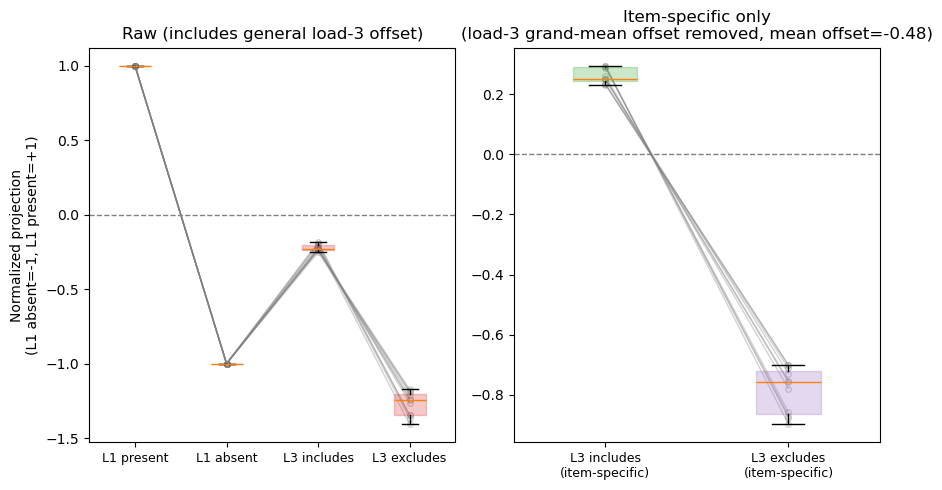

In [43]:
all_raw, all_item_specific, all_offsets = [], [], []
for model_name in model_names:

    other_labels='precomputed_balanced123'
    _, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                                all_models_dir = all_models_dir, load_LFP=False)

    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )

    # calculate rates during maintenance period for correct trials
    correct_idxs = np.where(trial_perfs == 1)[0]
    rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
    trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

    # cut trials to maintenance period only
    rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
    for i in range(rates_corr.shape[0]):
        load = trial_labels_corr[i, 0]
        delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
        delay_end = int(delay_start + settings["delay"])
        rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

    # get all loads
    load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
    load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
    load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

    # get dimensionality for each load
    load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
    load2_rates = rates_maint[load2_idxs, :, :] # trials x neurons x time
    load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

    # pass in X (trials x neurons, avg over maintenance period)
    load1_mean = np.mean(load1_rates, axis=2)  # trials x neurons
    load3_mean = np.mean(load3_rates, axis=2)  # trials x neurons
    X = np.concatenate([load1_mean, load3_mean], axis=0)  # trials x neurons

    # create load1_labels and load3_labels arrays
    load_1or3_idxs = np.concatenate([load1_idxs, load3_idxs], axis=0)
    load1_labels = np.array([label[2] if label[0] == 1 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-1 stim labels, None for non-load-1 trials
    load3_labels = np.array([frozenset(label[2:5]) if label[0] == 3 else None for label in trial_labels_corr[load_1or3_idxs]])  # load-3 stim labels, None for non-load-3 trials
    
    decoder_axes = {}
    load1_mask = np.array([lbl is not None for lbl in load1_labels])
    idx1 = np.where(load1_mask)[0]
    for s in range(4):
        y1 = np.array([1 if load1_labels[i] == s else 0 for i in idx1])
        clf = LinearSVC(C=1.0, max_iter=10000).fit(X[idx1], y1)
        decoder_axes[s] = clf.coef_.flatten() / np.linalg.norm(clf.coef_.flatten())

    raw, item_specific, offset = compute_normalized_projections_decomposed(
        X, load1_labels, load3_labels, decoder_axes)
    all_raw.append(raw)
    all_item_specific.append(item_specific)
    all_offsets.append(offset)

fig = plot_decomposed_across_models(all_raw, all_item_specific, all_offsets)
plt.show()

## Load 1 vs load 2

### one model

In [ ]:
model_name = model_names[10]

other_labels='precomputed_balanced123'
_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)

trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels,
        all_models_dir=all_models_dir
    )

# calculate rates during maintenance period for correct trials
correct_idxs = np.where(trial_perfs == 1)[0]
rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

# cut trials to maintenance period only
rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
for i in range(rates_corr.shape[0]):
    load = trial_labels_corr[i, 0]
    delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
    delay_end = int(delay_start + settings["delay"])
    rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

# get all loads
load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

# get dimensionality for each load
load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
load2_rates = rates_maint[load2_idxs, :, :] # trials x neurons x time
load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

# PCA of all loads together
n_trials_load1, n_neurons, n_time = load1_rates.shape
n_trials_load2, _, _ = load2_rates.shape
n_trials_load3, _, _ = load3_rates.shape
load1_vectors = load1_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load2_vectors = load2_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load3_vectors = load3_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons

X = np.concatenate([load1_vectors, load2_vectors,    load3_vectors], axis=0)  # trials x neurons
mu, sd = X.mean(0), X.std(0)
Xz = (X - mu) / sd

pca = PCA(n_components=300)
scores = pca.fit_transform(Xz)  # trials x components

n1 = load1_vectors.shape[0]
n2 = load2_vectors.shape[0]
n3 = load3_vectors.shape[0]
scores1, scores2, scores3 = scores[:n1], scores[n1:n1+n2], scores[n1+n2:n1+n2+n3]

load1_comps = scores1.reshape(n_trials_load1, n_time, -1) # trials x time x components
load2_comps = scores2.reshape(n_trials_load2, n_time, -1) # trials x time x components
load3_comps = scores3.reshape(n_trials_load3, n_time, -1) # trials x time x components

In [49]:
import numpy as np
from itertools import combinations

def betweenness_distance_test(X, load1_labels, load2_labels, n_stimuli=4, ref=None):
    """
    Distance-based betweenness test: for each load-2 pair (i,j), compute
    the relative 'detour' of the load-2 centroid M relative to the
    straight-line path between load-1 centroids A (stim i) and B (stim j):

        detour = (d(A,M) + d(M,B)) / d(A,B) - 1

    detour = 0  -> M lies exactly on the segment between A and B
    detour > 0  -> M deviates (perpendicular offset and/or overshoot),
                   grows with the size of the deviation

    Also returns the individual distance ratios d(A,M)/d(A,B) and
    d(M,B)/d(A,B), which should each be ~0.5 for a true midpoint
    (and sum to 1 + detour).
    """
    if ref is None:
        ref = np.zeros(X.shape[1])

    load1_mask = np.array([lbl is not None for lbl in load1_labels])
    load2_mask = np.array([pair is not None for pair in load2_labels])
    idx1, idx2 = np.where(load1_mask)[0], np.where(load2_mask)[0]

    load1_centroids = {
        s: X[idx1][np.array([load1_labels[i] == s for i in idx1])].mean(axis=0) - ref
        for s in range(n_stimuli)
    }
    stim_pairs = list(combinations(range(n_stimuli), 2))
    load2_centroids = {
        pair: X[idx2][np.array([
            (load2_labels[i] is not None) and (set(load2_labels[i]) == set(pair))
            for i in idx2
        ])].mean(axis=0) - ref
        for pair in stim_pairs
    }

    def detour(A, M, B):
        dAM = np.linalg.norm(M - A)
        dMB = np.linalg.norm(M - B)
        dAB = np.linalg.norm(B - A)
        return (dAM + dMB) / dAB - 1, dAM / dAB, dMB / dAB

    matched = {}
    for pair in stim_pairs:
        i, j = pair
        d, r1, r2 = detour(load1_centroids[i], load2_centroids[pair], load1_centroids[j])
        matched[pair] = {"detour": d, "ratio_to_i": r1, "ratio_to_j": r2}

    mismatched = []
    for pair in stim_pairs:
        for other in stim_pairs:
            if other == pair:
                continue
            k, l = other
            d, r1, r2 = detour(load1_centroids[k], load2_centroids[pair], load1_centroids[l])
            mismatched.append(d)

    matched_detours = np.array([v["detour"] for v in matched.values()])
    mismatched_detours = np.array(mismatched)

    return {
        "per_pair": matched,
        "matched_detour_mean": matched_detours.mean(),
        "matched_detour_std": matched_detours.std(),
        "mismatched_detour_mean": mismatched_detours.mean(),
        "mismatched_detour_std": mismatched_detours.std(),
    }

In [44]:
"""
For each load-2 pair (i,j), test whether the load-2 centroid sits
'between' the load-1 centroids for stim i and stim j.

X: (n_trials, n_neurons) population activity, maintenance-period average
load1_labels: len n_trials, entries in {0,1,2,3,None} for load-1 trials
load2_labels: len n_trials, entries are frozenset/tuple of 2 stim ids
                for load-2 trials, None otherwise
ref: optional reference to subtract (e.g. grand mean); if None, uses
        raw centroids (line-projection is invariant to a shared additive
        reference anyway, so this mostly matters for reporting scale)

Returns per-pair projection fraction (t) and normalized perpendicular
residual, plus a mismatched-pair control.
"""

# pass in X (trials x neurons, avg over maintenance period)
load1_mean = np.mean(load1_rates, axis=2)  # trials x neurons
load2_mean = np.mean(load2_rates, axis=2)  # trials x neurons
X_load12 = np.concatenate([load1_mean, load2_mean], axis=0)  # trials x neurons

# create load1_labels and load2_labels arrays
load_1or2_idxs = np.concatenate([load1_idxs, load2_idxs], axis=0)
load1_labels = np.array([label[2] if label[0] == 1 else None for label in trial_labels_corr[load_1or2_idxs]])  # load-1 stim labels, None for non-load-1 trials
load2_labels = np.array([frozenset(label[2:4]) if label[0] == 2 else None for label in trial_labels_corr[load_1or2_idxs]])  # load-2 stim labels, None for non-load-2 trials

In [50]:
results = betweenness_distance_test(X_load12, load1_labels, load2_labels, n_stimuli=4)

for pair, v in results["per_pair"].items():
    print(f"Pair {pair}: detour={v['detour']:.3f}, "
          f"ratio_to_i={v['ratio_to_i']:.3f}, ratio_to_j={v['ratio_to_j']:.3f}")

print(f"\nMatched detour: {results['matched_detour_mean']:.3f} ± {results['matched_detour_std']:.3f}")
print(f"Mismatched detour: {results['mismatched_detour_mean']:.3f} ± {results['mismatched_detour_std']:.3f}")

Pair (0, 1): detour=0.147, ratio_to_i=0.449, ratio_to_j=0.697
Pair (0, 2): detour=0.132, ratio_to_i=0.547, ratio_to_j=0.585
Pair (0, 3): detour=0.071, ratio_to_i=0.537, ratio_to_j=0.534
Pair (1, 2): detour=0.154, ratio_to_i=0.577, ratio_to_j=0.577
Pair (1, 3): detour=0.155, ratio_to_i=0.611, ratio_to_j=0.544
Pair (2, 3): detour=0.071, ratio_to_i=0.551, ratio_to_j=0.520

Matched detour: 0.122 ± 0.036
Mismatched detour: 0.558 ± 0.192


_Conclusion_

Load-2 [i,j] centroids lie close to the straight-line path between the corresponding load-1 stim-i and stim-j centroids, with a mean relative detour of 0.122 ± 0.036 across the 6 pairs — substantially smaller than for mismatched pairs (0.558 ± 0.192) — confirming that population activity for a two-item load approximates a linear combination of the corresponding single-item representations.

#### across models

In [51]:
results_list = []
for model_name in model_names:

    other_labels='precomputed_balanced123'
    _, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                                all_models_dir = all_models_dir, load_LFP=False)

    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )

    # calculate rates during maintenance period for correct trials
    correct_idxs = np.where(trial_perfs == 1)[0]
    rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
    trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

    # cut trials to maintenance period only
    rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
    for i in range(rates_corr.shape[0]):
        load = trial_labels_corr[i, 0]
        delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
        delay_end = int(delay_start + settings["delay"])
        rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

    # get all loads
    load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
    load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
    load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

    # get dimensionality for each load
    load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
    load2_rates = rates_maint[load2_idxs, :, :] # trials x neurons x time
    load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

    # PCA of all loads together
    n_trials_load1, n_neurons, n_time = load1_rates.shape
    n_trials_load2, _, _ = load2_rates.shape
    n_trials_load3, _, _ = load3_rates.shape
    load1_vectors = load1_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
    load2_vectors = load2_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
    load3_vectors = load3_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons

    X = np.concatenate([load1_vectors, load2_vectors,    load3_vectors], axis=0)  # trials x neurons
    mu, sd = X.mean(0), X.std(0)
    Xz = (X - mu) / sd

    pca = PCA(n_components=300)
    scores = pca.fit_transform(Xz)  # trials x components

    n1 = load1_vectors.shape[0]
    n2 = load2_vectors.shape[0]
    n3 = load3_vectors.shape[0]
    scores1, scores2, scores3 = scores[:n1], scores[n1:n1+n2], scores[n1+n2:n1+n2+n3]

    load1_comps = scores1.reshape(n_trials_load1, n_time, -1) # trials x time x components
    load2_comps = scores2.reshape(n_trials_load2, n_time, -1) # trials x time x components
    load3_comps = scores3.reshape(n_trials_load3, n_time, -1) # trials x time x components
    
    # pass in X (trials x neurons, avg over maintenance period)
    load1_mean = np.mean(load1_rates, axis=2)  # trials x neurons
    load2_mean = np.mean(load2_rates, axis=2)  # trials x neurons
    X_load12 = np.concatenate([load1_mean, load2_mean], axis=0)  # trials x neurons

    # create load1_labels and load2_labels arrays
    load_1or2_idxs = np.concatenate([load1_idxs, load2_idxs], axis=0)
    load1_labels = np.array([label[2] if label[0] == 1 else None for label in trial_labels_corr[load_1or2_idxs]])  # load-1 stim labels, None for non-load-1 trials
    load2_labels = np.array([frozenset(label[2:4]) if label[0] == 2 else None for label in trial_labels_corr[load_1or2_idxs]])  # load-2 stim labels, None for non-load-2 trials
    
    results = betweenness_distance_test(X_load12, load1_labels, load2_labels, n_stimuli=4)
    
    results_list.append(results)

    for pair, v in results["per_pair"].items():
        print(f"Pair {pair}: detour={v['detour']:.3f}, "
            f"ratio_to_i={v['ratio_to_i']:.3f}, ratio_to_j={v['ratio_to_j']:.3f}")

    print(f"\nMatched detour: {results['matched_detour_mean']:.3f} ± {results['matched_detour_std']:.3f}")
    print(f"Mismatched detour: {results['mismatched_detour_mean']:.3f} ± {results['mismatched_detour_std']:.3f}")

Pair (0, 1): detour=0.177, ratio_to_i=0.588, ratio_to_j=0.589
Pair (0, 2): detour=0.095, ratio_to_i=0.685, ratio_to_j=0.410
Pair (0, 3): detour=0.122, ratio_to_i=0.517, ratio_to_j=0.604
Pair (1, 2): detour=0.149, ratio_to_i=0.615, ratio_to_j=0.534
Pair (1, 3): detour=0.149, ratio_to_i=0.488, ratio_to_j=0.661
Pair (2, 3): detour=0.113, ratio_to_i=0.496, ratio_to_j=0.617

Matched detour: 0.134 ± 0.027
Mismatched detour: 0.632 ± 0.218
Pair (0, 1): detour=0.143, ratio_to_i=0.745, ratio_to_j=0.398
Pair (0, 2): detour=0.227, ratio_to_i=0.655, ratio_to_j=0.572
Pair (0, 3): detour=0.099, ratio_to_i=0.725, ratio_to_j=0.374
Pair (1, 2): detour=0.132, ratio_to_i=0.341, ratio_to_j=0.792
Pair (1, 3): detour=0.161, ratio_to_i=0.538, ratio_to_j=0.623
Pair (2, 3): detour=0.087, ratio_to_i=0.804, ratio_to_j=0.283

Matched detour: 0.142 ± 0.046
Mismatched detour: 0.891 ± 0.950
Pair (0, 1): detour=0.127, ratio_to_i=0.581, ratio_to_j=0.547
Pair (0, 2): detour=0.109, ratio_to_i=0.640, ratio_to_j=0.470
Pair

/tmp/ipykernel_956819/3861306975.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([matched_detours, mismatched_detours], labels=['Matched', 'Mismatched'])


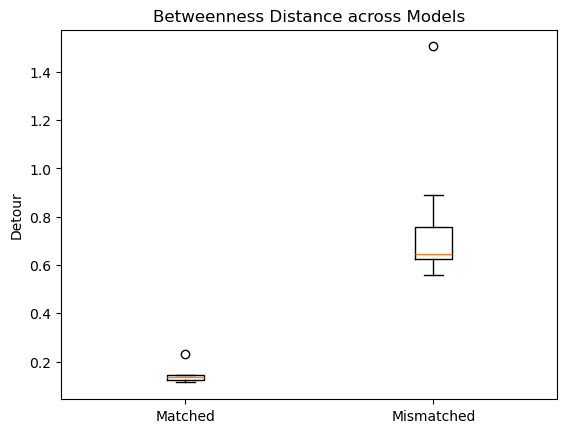

In [52]:
# plot matched detour and mismatched detour across models as boxplots
matched_detours = [r["matched_detour_mean"] for r in results_list]
mismatched_detours = [r["mismatched_detour_mean"] for r in results_list]

import matplotlib.pyplot as plt

plt.boxplot([matched_detours, mismatched_detours], labels=['Matched', 'Mismatched'])
plt.ylabel('Detour')
plt.title('Betweenness Distance across Models')
plt.show()
